In [1]:
import random
from abc import ABC, abstractmethod
from math import inf
from typing import Callable, Dict, List, Set, Tuple

import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

In [2]:
# %matplotlib inline

In [3]:
Tensor = torch.Tensor
Generator = torch.Generator

# Lecture 1: Bigrams

In [4]:
def read_data(data_path: str) -> List[str]:
    words = []
    with open(data_path, "r") as fh:
        for line in fh:
            words.append(line.strip())
    return words

In [5]:
words = read_data("names.txt")
print("Top ten words: ", words[:10])
print("Total words: ", len(words))
min_word_len = min([len(word) for word in words])
max_word_len = max([len(word) for word in words])
print("Min word length: ", min_word_len)
print("Max word length: ", max_word_len)

Top ten words:  ['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia', 'harper', 'evelyn']
Total words:  32033
Min word length:  2
Max word length:  15


In [6]:
SEED = 2147483647
# GENERATOR = Generator().manual_seed(SEED)


In [7]:
SPECIAL = "."
letters = sorted(list(set("".join(words))))
alphabet = [SPECIAL] + letters
LTOI = {l: i for i, l in enumerate(alphabet)}
ITOL = {i: l for i, l in enumerate(alphabet)}

In [8]:
# character level model - what char is likely to follow a char
def bigram_dict(words: List[str]) -> Dict[Tuple[str, str], int]:
    freq = {}
    for word in words:
        letters = [SPECIAL] + list(word) + [SPECIAL]
        for bg in zip(letters, letters[1:]):
            if bg in freq:
                freq[bg] += 1
            else:
                freq[bg] = 1
    return freq

In [9]:
words = read_data("names.txt")
model = bigram_dict(words)
least_freq_bg = sorted(model.items(), key=lambda x: x[1])[0]
print("Least frequent bigram: ", least_freq_bg)
most_freq_bg = sorted(model.items(), reverse=True, key=lambda x: x[1])[0]
print("Most frequent bigram: ", most_freq_bg)


Least frequent bigram:  (('q', 'r'), 1)
Most frequent bigram:  (('n', '.'), 6763)


In [10]:
def train_bigram_tensor(words: List[str], dim: int) -> Tensor:
    model = torch.zeros((dim, dim), dtype=torch.int32)
    for word in words:
        letters = [SPECIAL] + list(word) + [SPECIAL]
        for l1, l2 in zip(letters, letters[1:]):
            idx1, idx2 = LTOI[l1], LTOI[l2]
            model[idx1, idx2] += 1

    #  normalize tensor
    prob_dist = (model + 1).float()
    prob_dist /= prob_dist.sum(1, keepdim=True)
    return prob_dist

In [11]:
def apply_bigram_tensor(model: Tensor, max_iterations: int = 100, generator: Generator | None = None) -> str:
    generator = Generator().manual_seed(SEED) if generator is None else generator
    result = []

    idx = 0
    for _ in range(max_iterations):
        prob = model[idx]
        idx = torch.multinomial(prob, num_samples=1, replacement=True, generator=generator).item()
        result.append(ITOL[idx])
        if idx == 0:
            break
    return "".join(result)

In [12]:
def plot_bigram_tensor_model(model: Tensor, dim: int):
    plt.figure(figsize=(16, 16))
    plt.imshow(model, cmap="Reds")  # heatmaps feel like they should be red
    plt.axis("off")
    for i in range(dim):
        for j in range(dim):
            li = ITOL[i]
            lj = ITOL[j]
            if li is None or lj is None:
                continue
            plt.text(j, i, str(round(model[i, j].item(), 3)), ha="center", va="top")
            plt.text(j, i, li + lj, ha="center", va="bottom")
    return

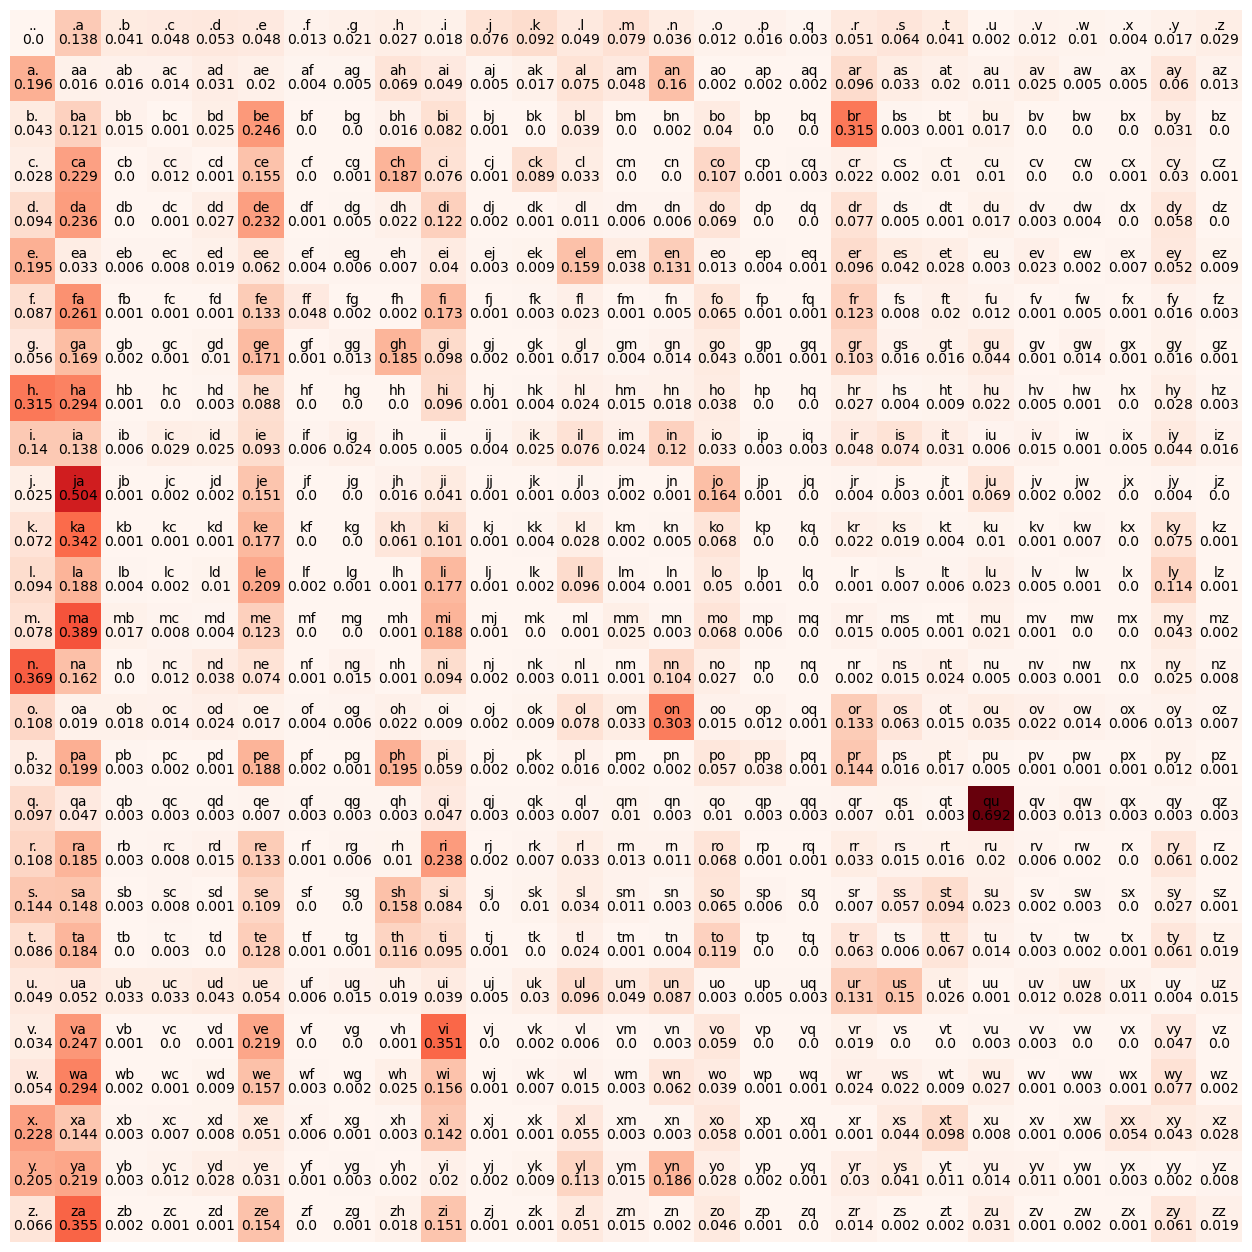

In [13]:
model = train_bigram_tensor(words, len(alphabet))
plot_bigram_tensor_model(model, len(alphabet))

In [14]:
for _ in range(10):
    result = apply_bigram_tensor(model)
    print(result)

cexze.
cexze.
cexze.
cexze.
cexze.
cexze.
cexze.
cexze.
cexze.
cexze.


In [15]:
def evaluate_bigram_tensor_model(model: Tensor) -> float:
    log_likelihood = 0.0
    n = 0
    for word in words:
        letters = [SPECIAL] + list(word) + [SPECIAL]
        for l1, l2 in zip(letters, letters[1:]):
            idx1, idx2 = LTOI[l1], LTOI[l2]
            log_likelihood += torch.log(model[idx1, idx2])
            n += 1
    return ((-1 * log_likelihood) / n).item()

In [16]:
log_likelihood = evaluate_bigram_tensor_model(model)
print("Log Likelihood: ", round(log_likelihood, 3))

Log Likelihood:  2.454


In [17]:
def create_bigram_training_set(words: List[str], dim: int) -> Tuple[Tensor, Tensor]:
    features, labels = [], []
    for word in words:
        letters = [SPECIAL] + list(word) + [SPECIAL]
        for l1, l2 in zip(letters, letters[1:]):
            idx1, idx2 = LTOI[l1], LTOI[l2]
            features.append(idx1)
            labels.append(idx2)

    features_t = torch.tensor(features)
    features_t = F.one_hot(features_t, num_classes=dim).float()

    labels_t = torch.tensor(labels)
    return features_t, labels_t

In [18]:
features_t, labels_t = create_bigram_training_set(words, len(alphabet))
print(features_t.shape)
print(labels_t.shape)

torch.Size([228146, 27])
torch.Size([228146])


In [19]:
def train_bigram_nn(
    features_t: Tensor,
    labels_t: Tensor,
    n_inputs: int,
    n_outputs: int,
    alpha: float = 0.1,
    epsilon: float = 10**-5,
    max_iterations: int = 100,
    verbose: bool = True,
    print_freq: int = 10,
    generator: Generator | None = None,
) -> Tuple[Tensor, Tensor]:

    generator = Generator().manual_seed(SEED) if generator is None else generator
    indices = torch.arange(len(labels_t))
    weights = torch.randn((n_inputs, n_outputs), requires_grad=True, generator=generator)
    probabilities = torch.zeros((n_inputs, n_outputs))
    prev_loss = inf
    for iteration in range(max_iterations):
        # softmax
        z = (features_t @ weights).exp()
        probabilities = z / z.sum(1, keepdim=True)

        # loss
        loss = -probabilities[indices, labels_t].log().mean()

        # backward pass
        weights.grad = None
        loss.backward()

        if loss > prev_loss:
            alpha /= 10

        if verbose and (iteration % print_freq == 0):
            print(f"{iteration}\t{loss:.6f}")

        weights.data += -alpha * weights.grad  # type: ignore
        if abs(loss - prev_loss) < epsilon:
            return (weights, probabilities)
        prev_loss = loss

    return weights, probabilities

In [20]:
weights, probabilities = train_bigram_nn(features_t, labels_t, len(alphabet), len(alphabet))

0	3.758953
10	3.749866
20	3.740883
30	3.732001
40	3.723219
50	3.714535
60	3.705945
70	3.697450
80	3.689046
90	3.680733


In [21]:
def evaluate_bigram_nn(probabilities: Tensor, labels_t: Tensor) -> float:
    n = 5
    log_likelihoods = torch.zeros(n)
    for i in range(n):
        y = labels_t[i]
        p = probabilities[i, y]
        logp = torch.log(p)
        log_likelihoods[i] = -logp
    return log_likelihoods.mean().item()

In [22]:
mean_log_likelihood = evaluate_bigram_nn(probabilities, labels_t)
print("Mean Log Likelihood: ", round(mean_log_likelihood, 3))

Mean Log Likelihood:  3.647


In [23]:
def apply_bigram_nn(weights: Tensor, dim: int, max_iterations: int = 100, generator: Generator | None = None) -> str:
    generator = Generator().manual_seed(SEED) if generator is None else generator

    result = []
    idx = 0
    for _ in range(max_iterations):
        x = F.one_hot(torch.tensor([idx]), num_classes=dim).float()
        z = x @ weights
        probabilities = z.exp()
        prob = probabilities / probabilities.sum(1, keepdim=True)
        idx = torch.multinomial(prob, num_samples=1, replacement=True, generator=generator).item()
        result.append(ITOL[idx])
        if idx == 0:
            break
    return "".join(result)

In [24]:
for _ in range(5):
    result = apply_bigram_nn(weights, len(alphabet))
    print(result)

zexzmkloglquszipczktxhkmpmzisttt.
zexzmkloglquszipczktxhkmpmzisttt.
zexzmkloglquszipczktxhkmpmzisttt.
zexzmkloglquszipczktxhkmpmzisttt.
zexzmkloglquszipczktxhkmpmzisttt.


# Lecture 2: MLP

In [25]:
MLP = List[Tuple[Tensor, Tensor]]

In [26]:
CONTEXT_SIZE = 3
EMBED_SIZE = 10

In [27]:
def generate_dataset(words: List[str], context_size: int) -> Tuple[Tensor, Tensor]:
    features, labels = [], []
    for word in words:
        context = [0] * context_size
        for char in word + ".":
            idx = LTOI[char]
            features.append(context)
            labels.append(idx)
            context = context[1:] + [idx]  # window

    features_t = torch.tensor(features)
    labels_t = torch.tensor(labels)
    return features_t, labels_t

In [28]:
features_t, labels_t = generate_dataset(words, CONTEXT_SIZE)

d1 = int(0.8 * len(words))
d2 = int(0.9 * len(words))
train_features, train_labels = generate_dataset(words[:d1], CONTEXT_SIZE)
print("Training set: ", train_features.shape)
dev_features, dev_labels = generate_dataset(words[d1:d2], CONTEXT_SIZE)
print("Dev set: ", dev_features.shape)
test_features, test_labels = generate_dataset(words[d2:], CONTEXT_SIZE)
print("Test set: ", test_features.shape)

Training set:  torch.Size([182778, 3])
Dev set:  torch.Size([22633, 3])
Test set:  torch.Size([22735, 3])


In [29]:
def pretty_print_dataset(features_t: Tensor, labels_t: Tensor, head: int = 20):
    for x, y in zip(features_t[:head], labels_t[:head]):
        print("".join(ITOL[ix.item()] for ix in x), "-->", ITOL[y.item()])
    return

In [30]:
pretty_print_dataset(train_features, train_labels)

... --> e
..e --> m
.em --> m
emm --> a
mma --> .
... --> o
..o --> l
.ol --> i
oli --> v
liv --> i
ivi --> a
via --> .
... --> a
..a --> v
.av --> a
ava --> .
... --> i
..i --> s
.is --> a
isa --> b


In [31]:
def create_embedding(n_inputs: int, lower_dim: int, generator: Generator) -> Tensor:
    embedding = torch.randn((n_inputs, lower_dim), requires_grad=True, generator=generator)
    return embedding

In [32]:
generator = Generator().manual_seed(SEED)

embedding = create_embedding(len(alphabet), EMBED_SIZE, generator)
print("Embedding: ", embedding.shape)

Embedding:  torch.Size([27, 10])


In [33]:
def init_mlp(n_inputs: int, n_hidden: int, n_outputs: int, n_layers: int, generator: Generator) -> MLP:
    weights1 = torch.randn((n_inputs, n_hidden), generator=generator, requires_grad=True)
    bias1 = torch.randn(n_hidden, generator=generator, requires_grad=True)

    weights2 = torch.randn((n_hidden, n_outputs), generator=generator, requires_grad=True)
    bias2 = torch.randn(n_outputs, generator=generator, requires_grad=True)
    model = [(weights1, bias1), (weights2, bias2)]
    return model

In [34]:
def feed_forward(batch: Tensor, network: MLP, training: bool = True):
    z1 = torch.tanh(batch @ network[0][0] + network[0][1])
    z2 = z1 @ network[1][0] + network[1][1]
    return z2

In [35]:
def train_mlp(
    features_t: Tensor,
    labels_t: Tensor,
    embedding: Tensor,
    network: MLP,
    feed_forward_fn: Callable,
    alpha: float = 0.1,
    batch_size: int = 32,
):
    # minibatch
    idx = torch.randint(0, features_t.shape[0], (batch_size,))
    batch = embedding[features_t[idx]]

    # softmax
    activations = feed_forward_fn(batch.view((batch.shape[0], -1)), network)
    loss = F.cross_entropy(activations, labels_t[idx])
    embedding.grad = None
    # backward pass
    for weights, bias in network:
        weights.grad = None
        if bias is not None:
            bias.grad = None

    loss.backward()
    embedding.data += -1 * alpha * embedding.grad  # type: ignore
    for weights, bias in network:
        weights.data += -1 * alpha * weights.grad  # type: ignore
        if bias is not None:
            bias.data += -1 * alpha * bias.grad  # type: ignore
    return loss

In [36]:
def learn_mlp(
    embedding: Tensor,
    features_t: Tensor,
    labels_t: Tensor,
    n_inputs: int,
    n_hidden: int,
    n_outputs: int,
    n_layers: int = 1,
    alpha: float = 0.1,
    epsilon: float =10**-5,
    max_iterations: int = 20000,
    verbose: bool = True,
    print_freq: int = 10000,
    generator: Generator | None = None,
    init_fn: Callable = init_mlp,
    feed_forward_fn: Callable = feed_forward,
    train_fn: Callable = train_mlp,
) -> tuple[MLP, list[Tensor]]:
    network = init_fn(n_inputs, n_hidden, n_outputs, n_layers, generator)
    prev_loss = inf
    losses = []
    for iteration in range(max_iterations):
        alpha = 0.1 if iteration < 100000 else 0.01

        loss = train_fn(features_t, labels_t, embedding, network, feed_forward_fn, alpha)
        losses.append(loss.log().item())

        if verbose and (iteration % print_freq == 0):
            print(f"{iteration}\t{loss:.6f}")

        if abs(loss - prev_loss) < epsilon:
            return network, losses
        prev_loss = loss

    return network, losses

In [37]:
@torch.no_grad()
def evaluate_mlp(train_features: Tensor, labels_t: Tensor, embedding: Tensor, network: MLP, feed_forward_fn: Callable) -> float:
    batch = embedding[train_features]
    batch = batch.view(batch.shape[0], -1)
    activations = feed_forward_fn(batch.view(batch.shape[0], -1), network)
    loss = F.cross_entropy(activations, labels_t)
    return loss.item()

In [38]:
@torch.no_grad()
def apply_model(embedding: Tensor, network: MLP, generator: Generator, max_iterations: int = 100, feed_forward_fn=feed_forward) -> str:
    result = []
    context = [0] * CONTEXT_SIZE
    for _ in range(max_iterations):
        batch = embedding[torch.tensor([context])]
        batch = batch.view(1, -1)
        activations = feed_forward_fn(batch, network, False)
        probabilities = torch.softmax(activations, dim=1)
        idx = torch.multinomial(probabilities, num_samples=1, generator=generator).item()
        context = context[1:] + [idx]
        result.append(ITOL[idx])
        if idx == 0:
            break
    return "".join(result)


In [39]:
def calibrate(embedding: Tensor, train_features: Tensor, network: Tensor):
    return

In [40]:
def run_model(
    train_features: Tensor,
    train_labels: Tensor,
    dev_features: Tensor,
    dev_labels: Tensor,
    test_features: Tensor,
    test_labels: Tensor,
    n_inputs: int,
    n_hidden: int,
    n_outputs: int,
    n_layers: int = 1,
    init_fn: Callable = init_mlp,
    train_fn: Callable = train_mlp,
    feed_forward_fn: Callable = feed_forward,
    calibrate_fn: Callable = calibrate,
):
    generator = Generator().manual_seed(SEED)

    embedding = create_embedding(n_outputs, EMBED_SIZE, generator)
    print("Iterations\tLoss")
    network, losses = learn_mlp(
        embedding, train_features, train_labels, n_inputs, n_hidden, n_outputs, n_layers, generator=generator, init_fn=init_fn, train_fn=train_fn, feed_forward_fn=feed_forward_fn
    )

    calibrate_fn(embedding, train_features, network)

    print("Loss while Training:")
    plt.plot(losses)
    plt.show()

    train_loss = evaluate_mlp(train_features, train_labels, embedding, network, feed_forward_fn)
    print("Training Loss: ", round(train_loss, 3))

    dev_loss = evaluate_mlp(dev_features, dev_labels, embedding, network, feed_forward_fn)
    print("Validation Loss: ", round(dev_loss, 3))

    test_loss = evaluate_mlp(test_features, test_labels, embedding, network, feed_forward_fn)
    print("Test Loss: ", round(test_loss, 3))

    print("\nApply Model:")
    for _ in range(20):
        result = apply_model(embedding, network, generator=generator, feed_forward_fn=feed_forward_fn)
        print("\t" + result)
    return network, losses

Iterations	Loss
0	23.886341
10000	2.766792
Loss while Training:


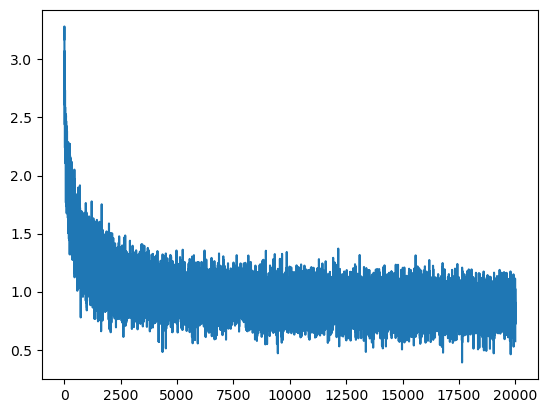

Training Loss:  2.512
Validation Loss:  2.861
Test Loss:  2.869

Apply Model:
	sar.
	gielynnid.
	aalina.
	meiupersiepenkinlyn.
	ranie.
	maleserineenlincetanrioniyanithenialen.
	nielinianeelindiena.
	aaehtinidanilla.
	tofina.
	andele.
	oolandelin.
	zairiea.
	tavganyatillanais.
	nielia.
	doralenin.
	nahiena.
	merinna.
	kerikheleenina.
	tamiina.
	neviniaten.


In [41]:
network, losses = run_model(train_features, train_labels, dev_features, dev_labels, test_features, test_labels, CONTEXT_SIZE * EMBED_SIZE, 200, len(alphabet))

# Lecture 3: batchnorm


In [42]:
# https://docs.pytorch.org/docs/stable/torch.html#inplace-random-sampling
def init_mlp_range_normalized(n_inputs: int, n_hidden: int, n_outputs: int, n_layers: int, generator: Generator, weight_range: float = 0.1) -> MLP:

    weights1 = torch.empty((n_inputs, n_hidden)).uniform_(-weight_range, weight_range, generator=generator).requires_grad_(True)
    bias1 = torch.empty(n_hidden).uniform_(-weight_range, weight_range, generator=generator).requires_grad_(True)
    weights2 = torch.empty((n_hidden, n_outputs)).uniform_(-weight_range, weight_range, generator=generator).requires_grad_(True)
    bias2 = torch.empty(n_outputs).uniform_(-weight_range, weight_range, generator=generator).requires_grad_(True)
    model = [(weights1, bias1), (weights2, bias2)]
    return model

Iterations	Loss
0	3.266989
10000	2.225161
Loss while Training:


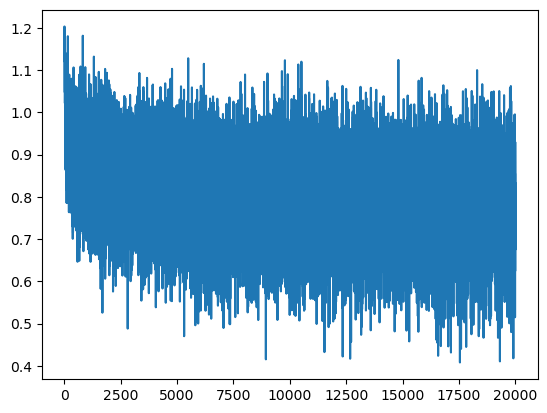

Training Loss:  2.168
Validation Loss:  2.442
Test Loss:  2.458

Apply Model:
	lila.
	diniah.
	amyanna.
	jelisra.
	tuwamilinni.
	kamiralaini.
	nas.
	khloisl.
	gyson.
	lumea.
	mara.
	lynn.
	skaile.
	makele.
	handoty.
	cley.
	scaelian.
	tolce.
	emilah.
	walliannah.


In [43]:
_ = run_model(train_features, train_labels, dev_features, dev_labels, test_features, test_labels, CONTEXT_SIZE * EMBED_SIZE, 200, len(alphabet), init_fn=init_mlp_range_normalized)

In [44]:
def init_mlp_kaiming_normalized(n_inputs: int, n_hidden: int, n_outputs: int, n_layers: int, generator: Generator, weight_range: float = 0.1) -> MLP:
    kaiming_std = (5 / 3) / ((EMBED_SIZE * CONTEXT_SIZE) ** 0.5)
    weights1 = torch.randn((n_inputs, n_hidden), generator=generator) * kaiming_std
    bias1 = torch.randn(n_hidden, generator=generator) * 0.01

    weights2 = torch.randn((n_hidden, n_outputs), generator=generator) * 0.01
    bias2 = torch.empty(n_outputs).uniform_(-weight_range, weight_range, generator=generator)

    for t in [weights1, bias1, weights2, bias2]:
        t.requires_grad = True

    model = [(weights1, bias1), (weights2, bias2)]
    return model

Iterations	Loss
0	3.307878
10000	2.090077
Loss while Training:


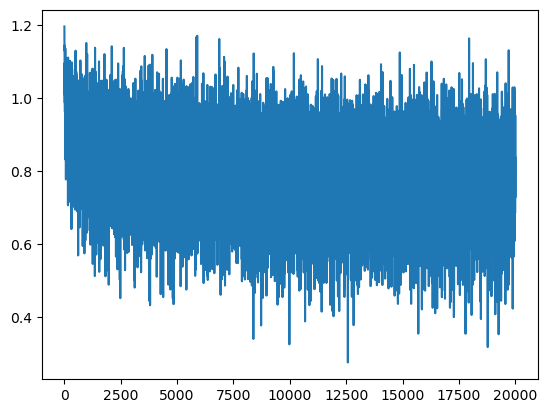

Training Loss:  2.131
Validation Loss:  2.422
Test Loss:  2.452

Apply Model:
	emaela.
	trayliana.
	angeret.
	brie.
	gruy.
	gyanna.
	jaymitza.
	aminasi.
	trukeeigh.
	kayah.
	jiabet.
	antevy.
	ankeiraya.
	sayda.
	dinoria.
	caleiani.
	daniyah.
	alaymiwwenis.
	traya.
	carlideano.


In [45]:
_ = run_model(
    train_features,
    train_labels,
    dev_features,
    dev_labels,
    test_features,
    test_labels,
    CONTEXT_SIZE * EMBED_SIZE,
    200,
    len(alphabet),
    init_fn=init_mlp_kaiming_normalized,
)

In [46]:
def init_mlp_batch_normalized(n_inputs: int, n_hidden: int, n_outputs: int, n_layers: int, generator: Generator) -> MLP:
    batchnorm_gain = torch.ones((1, n_hidden))
    batchnorm_bias = torch.zeros((1, n_hidden))

    batchnorm_mean = torch.ones((1, n_hidden))
    batchnorm_std = torch.zeros((1, n_hidden))

    kaiming_std = (5 / 3) / ((n_inputs) ** 0.5)
    weights1 = torch.randn((n_inputs, n_hidden), generator=generator) * kaiming_std
    bias1 = torch.randn(n_hidden, generator=generator) * 0.01

    weights2 = torch.randn((n_hidden, n_outputs), generator=generator) * 0.01
    bias2 = torch.zeros(n_outputs)

    model = [(weights1, bias1), (weights2, bias2), (batchnorm_gain, batchnorm_bias), (batchnorm_mean, batchnorm_std)]
    for weight, bias in model:
        weight.requires_grad = True
        bias.requires_grad = True
    return model

In [47]:
def feed_forward_batchnorm(batch: Tensor, network: MLP, training: bool = True):
    z1 = torch.tanh(batch @ network[0][0] + network[0][1])
    mean = z1.mean(0, keepdim=True) if training else network[3][0]
    stdev = z1.std(0, keepdim=True) if training else network[3][1]

    z1 = (z1 - mean) / stdev
    z1 = network[2][0] * z1 + network[2][1]
    z2 = z1 @ network[1][0] + network[1][1]
    return z2

In [48]:
def train_batch_normalization(
    features_t: Tensor,
    labels_t: Tensor,
    embedding: Tensor,
    network: MLP,
    feed_forward_fn: Callable = feed_forward_batchnorm,
    alpha: float = 0.1,
    batch_size: int = 32,
):
    # minibatch
    idx = torch.randint(0, features_t.shape[0], (batch_size,))
    batch = embedding[features_t[idx]]
    batch = batch.view((batch.shape[0], -1))
    # softmax

    activations = feed_forward_fn(batch, network)
    loss = F.cross_entropy(activations, labels_t[idx])

    embedding.grad = None
    # backward pass
    for weights, bias in network[:-1]:
        weights.grad = None
        if bias is not None:
            bias.grad = None

    loss.backward()
    embedding.data += -1 * alpha * embedding.grad  # type: ignore
    for weights, bias in network[:-1]:
        weights.data += -1 * alpha * weights.grad  # type: ignore
        if bias is not None:
            bias.data += -1 * alpha * bias.grad  # type: ignore
    return loss

In [49]:
def calibrate_batchnorm(embedding: Tensor, train_features: Tensor, network: Tensor):
    batch = embedding[train_features]
    z1 = batch.view(batch.shape[0], -1) @ network[0][0]
    network[3] = (z1.mean(0, keepdim=True), z1.std(0, keepdim=True))  # type: ignore
    return

Iterations	Loss
0	3.355106
10000	1.892376
Loss while Training:


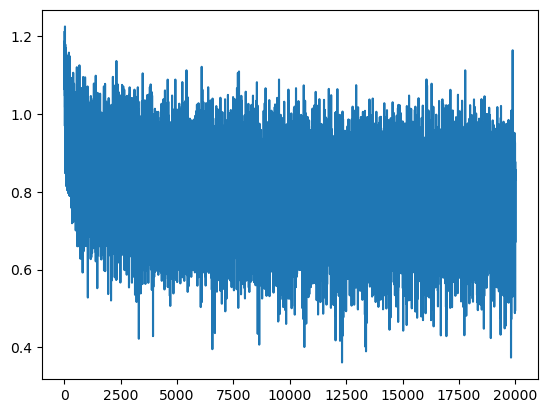

Training Loss:  2.132
Validation Loss:  2.409
Test Loss:  2.426

Apply Model:
	eeianee.
	uaaiireeera.
	ie.
	eeei.
	.
	rieaeyioen.
	p.
	kysminah.
	teanyaleene.
	leiyliaaaoimeyeuaseia.
	kae.
	eitki.
	pyene.
	keie.
	eie.
	aieeeee.
	yisheerieil.
	eica.
	aciylyaoineaherpdinaeeielireaiabbayaeo.
	leieihalleyseeanh.


In [50]:
network, losses = run_model(
    train_features,
    train_labels,
    dev_features,
    dev_labels,
    test_features,
    test_labels,
    CONTEXT_SIZE * EMBED_SIZE,
    200,
    len(alphabet),
    init_fn=init_mlp_batch_normalized,
    train_fn=train_batch_normalization,
    feed_forward_fn=feed_forward_batchnorm,
    calibrate_fn=calibrate_batchnorm,
)

In [51]:
def feed_forward_calibrate_batchnorm(batch: Tensor, network: MLP, training: bool = True):
    z1 = torch.tanh(batch @ network[0][0] + network[0][1])
    mean = z1.mean(0, keepdim=True) if training else network[3][0]
    stdev = z1.std(0, keepdim=True) if training else network[3][1]

    if training:
        with torch.no_grad():
            running_mean = 0.999 * network[3][0] + 0.001 * mean
            running_stdev = 0.999 * network[3][1] + 0.001 * stdev
            network[3] = (running_mean, running_stdev)

    z1 = (z1 - mean) / stdev
    z1 = network[2][0] * z1 + network[2][1]
    z2 = z1 @ network[1][0] + network[1][1]
    return z2

Iterations	Loss
0	3.336819
10000	2.380754
Loss while Training:


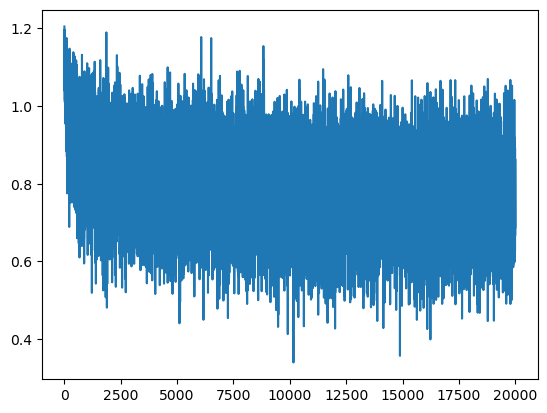

Training Loss:  2.125
Validation Loss:  2.396
Test Loss:  2.413

Apply Model:
	ceran.
	tera.
	narah.
	jaria.
	meli.
	kristemilly.
	pamysha.
	shaurancalenny.
	leigh.
	ara.
	imaheulle.
	a.
	kan.
	jotki.
	pren.
	joeily.
	hayli.
	maverlisha.
	saril.
	nica.


In [52]:
network, losses = run_model(
    train_features,
    train_labels,
    dev_features,
    dev_labels,
    test_features,
    test_labels,
    CONTEXT_SIZE * EMBED_SIZE,
    200,
    len(alphabet),
    init_fn=init_mlp_batch_normalized,
    train_fn=train_batch_normalization,
    feed_forward_fn=feed_forward_calibrate_batchnorm,
)

In [53]:
# OOPS
class Layer(ABC):
    def __init__(self, *args) -> None:
        self.out = None

    @abstractmethod
    def __call__(self, x: Tensor) -> Tensor:
        pass

    @abstractmethod
    def nodes(self) -> List[Tensor]:
        pass

    def retain_grad(self):
        if self.out is not None:
            self.out.retain_grad()


class Linear(Layer):
    def __init__(self, n_inputs: int, n_hidden: int, generator: Generator, bias: bool = True, gain: float | None = None):
        super().__init__()
        gain_val = (5 / 3) / ((n_inputs) ** 0.5) if gain is None else gain
        self.weight = torch.randn((n_inputs, n_hidden), generator=generator) * gain_val
        self.bias = torch.randn(n_hidden, generator=generator) * 0.01 if bias else None

    def __call__(self, x: Tensor):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out

    def nodes(self):
        nodes = [self.weight]
        if self.bias is not None:
            nodes.append(self.bias)
        return nodes


class BatchNormalization(Layer):
    def __init__(self, n_hidden: int, training: bool = True, gain_coef: float = 1.0):
        super().__init__()
        self.training = training
        self.gain = torch.ones(n_hidden) * gain_coef
        self.bias = torch.zeros(n_hidden)
        self.running_mean = torch.zeros(n_hidden)
        self.running_var = torch.ones(n_hidden)

    def __call__(self, x: Tensor, momentum: float = 0.1, epsilon: float = 0.001):
        mean = x.mean(0, keepdim=True) if self.training else self.running_mean
        var = x.var(0, keepdim=True) if self.training else self.running_var

        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - momentum) * self.running_mean + momentum * mean
                self.running_var = (1 - momentum) * self.running_var + momentum * var

        z1 = (x - mean) / torch.sqrt(var + epsilon)
        self.out = self.gain * z1 + self.bias
        return self.out

    def nodes(self):
        return [self.gain, self.bias]


class Tanh(Layer):
    def __init__(self) -> None:
        super().__init__()

    def __call__(self, x: Tensor):
        self.out = torch.tanh(x)
        return self.out

    def nodes(self):
        return []


class Embedding(Layer):
    def __init__(self, n_inputs: int, embed_size: int) -> None:
        super().__init__()
        self.weight = torch.randn((n_inputs, embed_size))

    def __call__(self, x: Tensor):
        self.out = self.weight[x]
        return self.out

    def nodes(self):
        return [self.weight]


class Flatten(Layer):
    def __call__(self, x: Tensor):
        self.out = x.view((x.shape[0], -1))
        return self.out

    def nodes(self):
        return []

In [54]:
DNN = List[Layer]

In [55]:
def init_dnn(n_inputs: int, n_hidden: int, n_outputs: int, n_layers: int, generator: Generator) -> DNN:
    network: DNN = [
        # input layer
        Linear(n_inputs, n_hidden, generator, False),
        BatchNormalization(n_hidden),
        Tanh(),
    ]

    for _ in range(n_layers):
        network.append(Linear(n_hidden, n_hidden, generator, False))
        network.append(BatchNormalization(n_hidden))
        network.append(Tanh())
    # output layer
    network.append(Linear(n_hidden, n_outputs, generator, False))
    network.append(BatchNormalization(n_outputs, gain_coef=0.1))

    for layer in network:
        for node in layer.nodes():
            node.requires_grad = True
    return network

In [56]:
def feed_forward_dnn(batch: Tensor, network: DNN, training: bool = True):
    for layer in network:
        if isinstance(layer, BatchNormalization):
            layer.training = training
        batch = layer(batch)
    return batch

In [57]:
def train_dnn(
    features_t: Tensor,
    labels_t: Tensor,
    embedding: Tensor,
    network: DNN,
    feed_forward_fn: Callable,
    alpha: float = 0.1,
    batch_size: int = 32,
):
    # minibatch
    idx = torch.randint(0, features_t.shape[0], (batch_size,))
    batch = embedding[features_t[idx]]

    # softmax
    activations = feed_forward_fn(batch.view((batch.shape[0], -1)), network)
    loss = F.cross_entropy(activations, labels_t[idx])

    embedding.grad = None

    for layer in network:
        layer.retain_grad()
        for node in layer.nodes():
            node.grad = None

    loss.backward()
    embedding.data += -1 * alpha * embedding.grad  # type: ignore

    for layer in network:
        for node in layer.nodes():
            node.data += -1 * alpha * node.grad  # type: ignore
    return loss

Iterations	Loss
0	3.290092
10000	2.197705
Loss while Training:


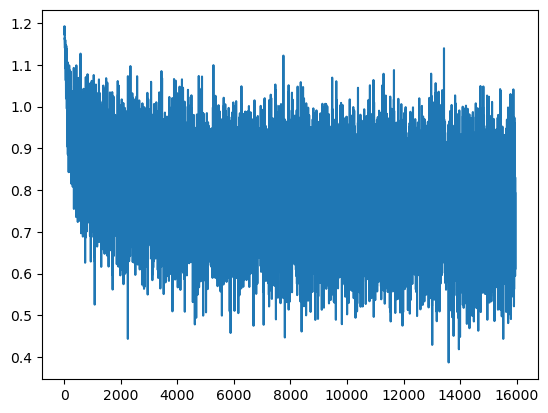

Training Loss:  2.094
Validation Loss:  2.378
Test Loss:  2.403

Apply Model:
	erikye.
	arionnuogurnealyn.
	bellyn.
	aruwina.
	aiston.
	iam.
	aryellor.
	shel.
	avayane.
	britynu.
	jadlynn.
	brin.
	lemarikaadian.
	aiah.
	harsle.
	daulecee.
	aautixgar.
	mas.
	braeli.
	vithmie.


In [58]:
# DNN model
network, losses = run_model(
    train_features,
    train_labels,
    dev_features,
    dev_labels,
    test_features,
    test_labels,
    CONTEXT_SIZE * EMBED_SIZE,
    200,
    len(alphabet),
    n_layers=4,
    init_fn=init_dnn,
    train_fn=train_dnn,
    feed_forward_fn=feed_forward_dnn,
)

layer 2 (      Tanh): mean -0.02, std 0.66, saturated: 6.00%
layer 5 (      Tanh): mean -0.03, std 0.67, saturated: 7.00%
layer 8 (      Tanh): mean +0.01, std 0.66, saturated: 8.50%
layer 11 (      Tanh): mean -0.04, std 0.64, saturated: 4.50%
layer 14 (      Tanh): mean -0.08, std 0.65, saturated: 3.00%


Text(0.5, 1.0, 'activation distribution')

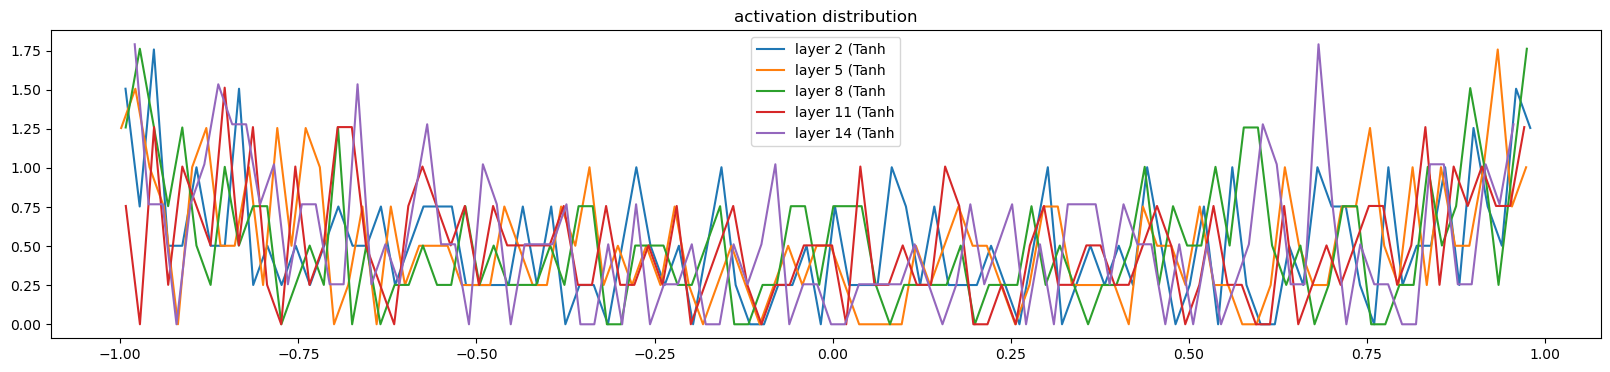

In [59]:
# visualize histograms
plt.figure(figsize=(20, 4))  # width and height of the plot
legends = []
for i, layer in enumerate(network[:-1]):  # note: exclude the output layer
    if isinstance(layer, Tanh):
        t = layer.out
        print("layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%" % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean() * 100))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f"layer {i} ({layer.__class__.__name__}")
plt.legend(legends)
plt.title("activation distribution")

# Lecture 4: backprop


In [60]:
def backprop():
    return

# Lecture 5: cnn

In [61]:
CONTEXT_SIZE = 8
EMBED_SIZE = 24

In [62]:
features_t, labels_t = generate_dataset(words, CONTEXT_SIZE)

d1 = int(0.8 * len(words))
d2 = int(0.9 * len(words))
train_features, train_labels = generate_dataset(words[:d1], CONTEXT_SIZE)
print("Training set: ", train_features.shape)
dev_features, dev_labels = generate_dataset(words[d1:d2], CONTEXT_SIZE)
print("Dev set: ", dev_features.shape)
test_features, test_labels = generate_dataset(words[d2:], CONTEXT_SIZE)
print("Test set: ", test_features.shape)

Training set:  torch.Size([182778, 8])
Dev set:  torch.Size([22633, 8])
Test set:  torch.Size([22735, 8])


In [63]:
class Layer(ABC):
    def __init__(self, *args) -> None:
        self.out = None
        self.training = True

    @abstractmethod
    def __call__(self, x: Tensor) -> Tensor:
        pass

    @abstractmethod
    def nodes(self) -> List[Tensor]:
        pass

    def retain_grad(self):
        if self.out is not None:
            self.out.retain_grad()


class Linear(Layer):
    def __init__(self, n_inputs: int, n_hidden: int, generator: Generator, bias: bool = True, gain: float | None = None):
        super().__init__()
        gain_val = (5 / 3) / ((n_inputs) ** 0.5) if gain is None else gain
        self.weight = torch.randn((n_inputs, n_hidden), generator=generator) * gain_val
        self.bias = torch.randn(n_hidden, generator=generator) * 0.01 if bias else None

    def __call__(self, x: Tensor):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out

    def nodes(self):
        nodes = [self.weight]
        if self.bias is not None:
            nodes.append(self.bias)
        return nodes


class BatchNormalization(Layer):
    def __init__(self, n_hidden: int, training: bool = True, gain_coef: float = 1.0):
        super().__init__()
        self.training = training
        self.gain = torch.ones(n_hidden) * gain_coef
        self.bias = torch.zeros(n_hidden)
        self.running_mean = torch.zeros(n_hidden)
        self.running_var = torch.ones(n_hidden)

    def __call__(self, x: Tensor, momentum: float = 0.1, epsilon: float = 0.001):        
        dim = (0,1) if x.ndim == 3 else 0 

        mean = x.mean(dim, keepdim=True) if self.training else self.running_mean
        var = x.var(dim, keepdim=True) if self.training else self.running_var

        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - momentum) * self.running_mean + momentum * mean
                self.running_var = (1 - momentum) * self.running_var + momentum * var

        z1 = (x - mean) / torch.sqrt(var + epsilon)
        self.out = self.gain * z1 + self.bias
        return self.out

    def nodes(self):
        return [self.gain, self.bias]


class Tanh(Layer):
    def __init__(self) -> None:
        super().__init__()

    def __call__(self, x: Tensor):
        self.out = torch.tanh(x)
        return self.out

    def nodes(self):
        return []


class Embedding(Layer):
    def __init__(self, n_inputs: int, embed_size: int) -> None:
        super().__init__()
        self.weight = torch.randn((n_inputs, embed_size))

    def __call__(self, x: Tensor):
        self.out = self.weight[x]
        return self.out

    def nodes(self):
        return [self.weight]


class Flatten(Layer):
    def __call__(self, x: Tensor):
        self.out = x.view((x.shape[0], -1))
        return self.out

    def nodes(self):
        return []


class FlattenConsecutive(Layer):
    def __init__(self, n):
        self.n = n

    def __call__(self, x):
        B, T, C = x.shape
        x = x.view(B, T // self.n, C * self.n)
        if x.shape[1] == 1:
            x = x.squeeze(1)
        self.out = x
        return self.out

    def nodes(self):
        return []


class Sequential(Layer):
    def __init__(self, layers: List[Layer]):
        self.layers = layers

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        self.out = x
        return self.out

    def nodes(self):
        return [p for layer in self.layers for p in layer.nodes()]

    def append(self, layer: Layer):
        self.layers.append(layer)

In [ ]:
class Network:
    def __init__(self, n_layers: int, n_hidden: int, n_outputs: int, embed_size: int, generator: Generator | None = None) -> None:
        if generator is None:
            self.generator = Generator().manual_seed(SEED)

        self.model = Sequential([Embedding(n_outputs, embed_size)])
        # self.model = Sequential([Embedding(n_outputs, embed_size), Flatten()])

        for i in range(n_layers):
            curr_input = embed_size if i == 0 else n_hidden
            self.model.append(FlattenConsecutive(2))
            self.model.append(Linear(curr_input * 2, n_hidden, self.generator, False))
            self.model.append(BatchNormalization(n_hidden))
            self.model.append(Tanh())

        # output layer
        self.model.append(Linear(n_hidden, n_outputs, self.generator, False))

        with torch.no_grad():
            self.model.layers[-1].weight *= 0.1  # type: ignore

        for node in self.model.nodes():
            node.requires_grad = True

    def train(
        self,
        features_t: Tensor,
        labels_t: Tensor,
        alpha: float = 0.1,
        batch_size: int = 32,
    ):
        idx = torch.randint(0, features_t.shape[0], (batch_size,))
        feature_batch = features_t[idx]

        z = self.model(feature_batch)
        loss = F.cross_entropy(z, labels_t[idx])

        for node in self.model.nodes():
            node.grad = None

        loss.backward()
        for node in self.model.nodes():
            node.data += -1 * alpha * node.grad  # type: ignore

        return loss

    def learn(self, epsilon: float = 10**-5, max_iterations: int = 20000, verbose: bool = True, print_freq: int = 10000):
        prev_loss = inf
        losses = []
        for iteration in range(max_iterations):
            alpha = 0.1 if iteration < 100000 else 0.01

            loss = self.train(features_t, labels_t, alpha)
            losses.append(loss.log().item())

            if verbose and (iteration % print_freq == 0):
                print(f"{iteration}\t{loss:.6f}")

            if abs(loss - prev_loss) < epsilon:
                break
            prev_loss = loss

        for layer in self.model.layers:
            layer.training = False
        return network, losses

    def evaluate(self, features_t: Tensor, labels_t: Tensor) -> float:

        z = self.model(features_t)  # handle training = true
        loss = F.cross_entropy(z, labels_t)
        return loss.item()

    def apply(self, context_size: int, max_iterations: int = 100) -> str:
        result = []
        context = [0] * context_size
        for _ in range(max_iterations):
            z = self.model(torch.tensor([context]))
            probabilities = F.softmax(z, dim=1)
            idx = torch.multinomial(probabilities, num_samples=1, generator=self.generator).item()
            context = context[1:] + [idx]
            result.append(ITOL[idx]) # type: ignore
            if idx == 0:
                break
        return "".join(result)

In [65]:
network = Network(3, 128, len(alphabet), 10)
network.learn()
train_loss = network.evaluate(train_features, train_labels)
print("Training Loss: ", round(train_loss, 3))

dev_loss = network.evaluate(dev_features, dev_labels)
print("Validation Loss: ", round(dev_loss, 3))

test_loss = network.evaluate(test_features, test_labels)
print("Test Loss: ", round(test_loss, 3))

print("\nApply Model:")
for _ in range(20):
    result = network.apply(CONTEXT_SIZE)
    print("\t" + result)

0	3.303136
Training Loss:  2.161
Validation Loss:  2.327
Test Loss:  2.352

Apply Model:
	aydaley.
	ayaly.
	jneva.
	bett.
	kacrion.
	yaizelee.
	kynoi.
	kaha.
	kenna.
	trisely.
	aati.
	abrise.
	rafny.
	yah.
	andela.
	saris.
	krichil.
	jeplima.
	arraskay.
	sapor.
